In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   row_id           9994 non-null   int64  
 1   order_id         9994 non-null   str    
 2   order_date       9994 non-null   str    
 3   ship_date        9994 non-null   str    
 4   ship_mode        9994 non-null   str    
 5   customer_id      9994 non-null   str    
 6   segment          9994 non-null   str    
 7   city             9994 non-null   str    
 8   state            9994 non-null   str    
 9   postal_code      9994 non-null   int64  
 10  region           9994 non-null   str    
 11  product_id       9994 non-null   str    
 12  category         9994 non-null   str    
 13  sub-category     9994 non-null   str    
 14  product_name     9994 non-null   str    
 15  sales            9994 non-null   float64
 16  quantity         9994 non-null   int64  
 17  discount         9994 non

C:\Users\Dan\AppData\Local\Temp\ipykernel_3732\90250135.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_for_corr.select_dtypes(include=['object']).columns


Top coerelatii pentru Profit:
profit            1.000000
sales             0.479064
category          0.091506
product_id        0.074791
quantity          0.066253
city              0.024217
region            0.022216
segment           0.013355
ship_day          0.007180
year              0.004670
order_year        0.004670
ship_year         0.004531
ship_date         0.004127
order_date        0.004118
customer_id       0.000798
order_month      -0.000502
ship_month       -0.000951
product_name     -0.001634
order_day        -0.002965
shipping_delay   -0.004649
ship_mode        -0.006619
order_id         -0.017873
state            -0.025315
sub-category     -0.029503
postal_code      -0.029961
discount         -0.219487
Name: profit, dtype: float64


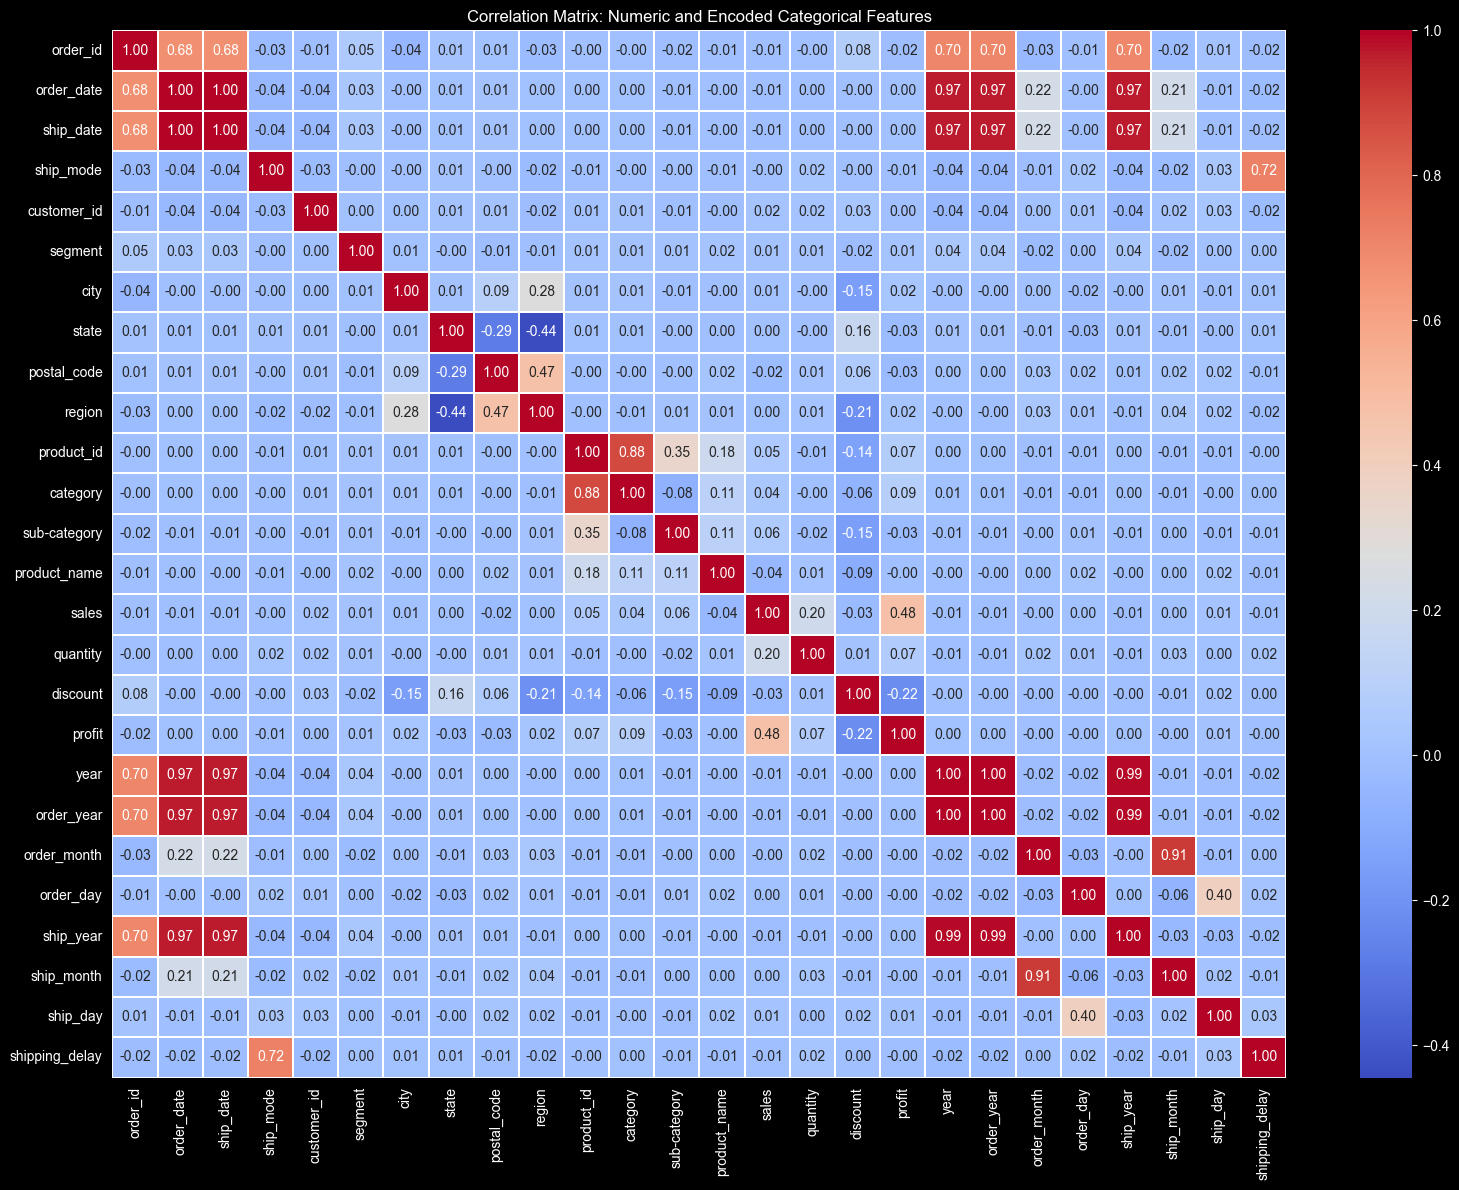

In [2]:
#matricea de corelatie pe profitul la nivel de rand

raw_data = pd.read_csv(r'..\data\processed\df_preprocessed.csv')
raw_data.info()

cols_to_drop = ['row_id', 'profit_per_unit', 'sales_per_unit']
df_for_corr = raw_data.drop(columns=[col for col in cols_to_drop if col in raw_data.columns])
le = LabelEncoder()
categorical_cols = df_for_corr.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_for_corr[col] = le.fit_transform(df_for_corr[col].astype(str))
corr_matrix = df_for_corr.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.1)
plt.title('Correlation Matrix: Numeric and Encoded Categorical Features')
plt.tight_layout()

plt.savefig('correlation_graphs/full_correlation_matrix.png')

print("Top coerelatii pentru Profit:")
print(corr_matrix['profit'].sort_values(ascending=False))

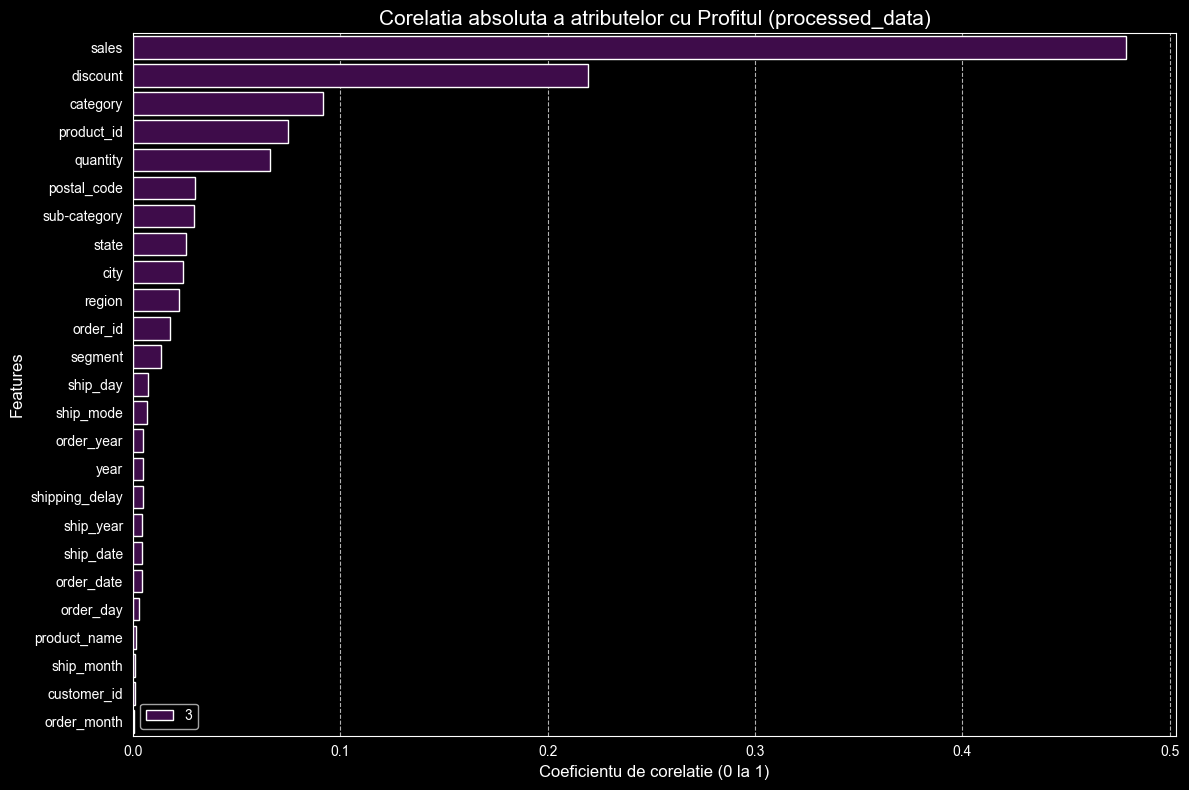

sales             0.479064
discount          0.219487
category          0.091506
product_id        0.074791
quantity          0.066253
postal_code       0.029961
sub-category      0.029503
state             0.025315
city              0.024217
region            0.022216
order_id          0.017873
segment           0.013355
ship_day          0.007180
ship_mode         0.006619
order_year        0.004670
year              0.004670
shipping_delay    0.004649
ship_year         0.004531
ship_date         0.004127
order_date        0.004118
order_day         0.002965
product_name      0.001634
ship_month        0.000951
customer_id       0.000798
order_month       0.000502
Name: profit, dtype: float64


<Figure size 640x480 with 0 Axes>

In [3]:
# features cu corelatie pentru profit
profit_corr = corr_matrix['profit'].abs().sort_values(ascending=False)
profit_corr = profit_corr.drop(labels=['profit'])

plt.figure(figsize=(12, 8))
sns.barplot(x=profit_corr.values, y=profit_corr.index, palette='viridis', hue=3)
plt.title('Corelatia absoluta a atributelor cu Profitul (processed_data)', fontsize=15)
plt.xlabel('Coeficientu de corelatie (0 la 1)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
plt.savefig('correlation_graphs/full_correlation_features.png')
print(profit_corr)

Observam o corelatie slaba (sub.0.5) a oricarui feature fata de profit

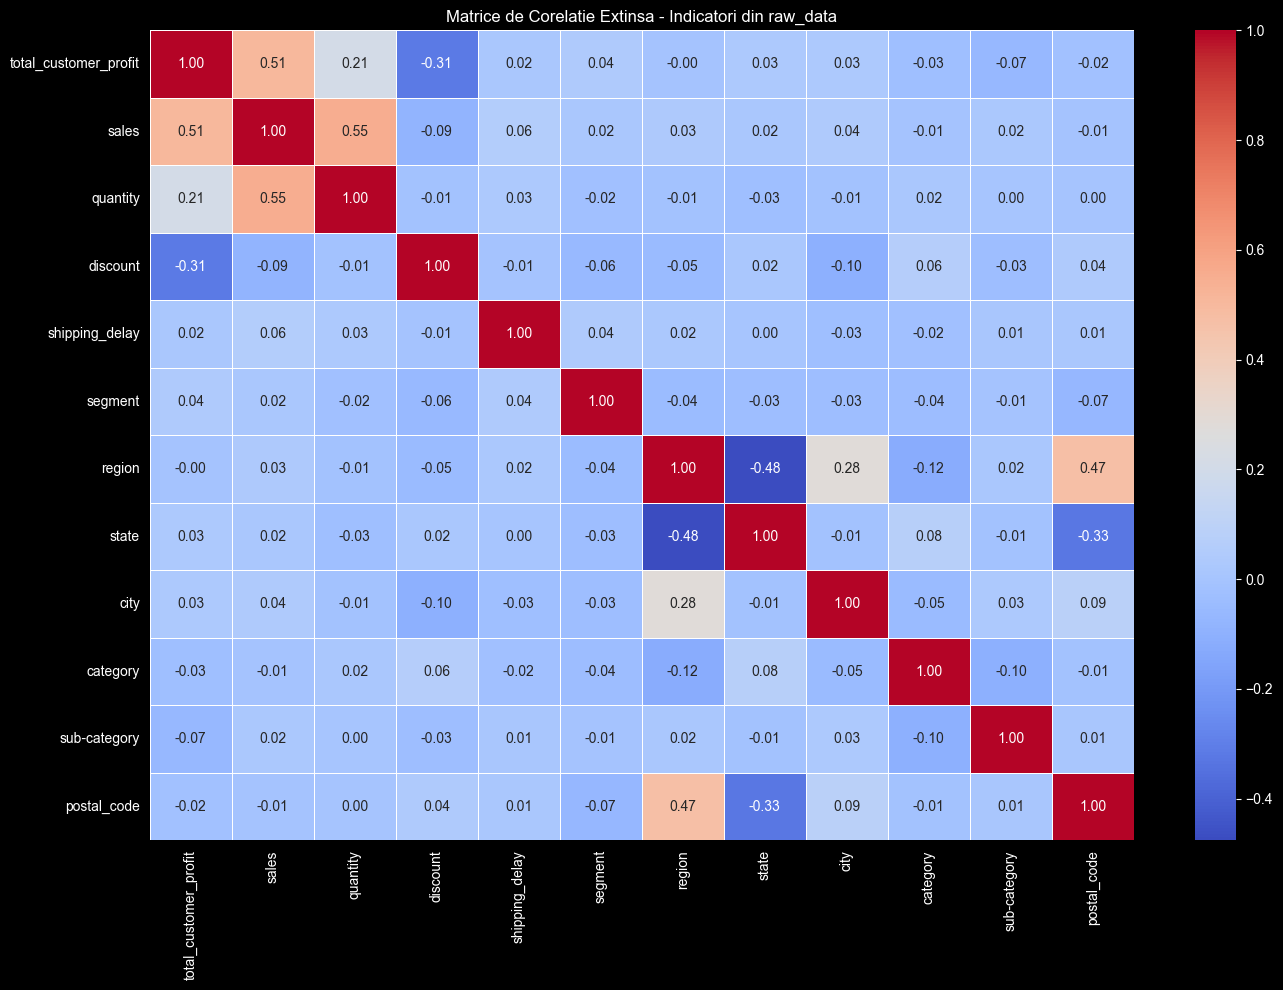

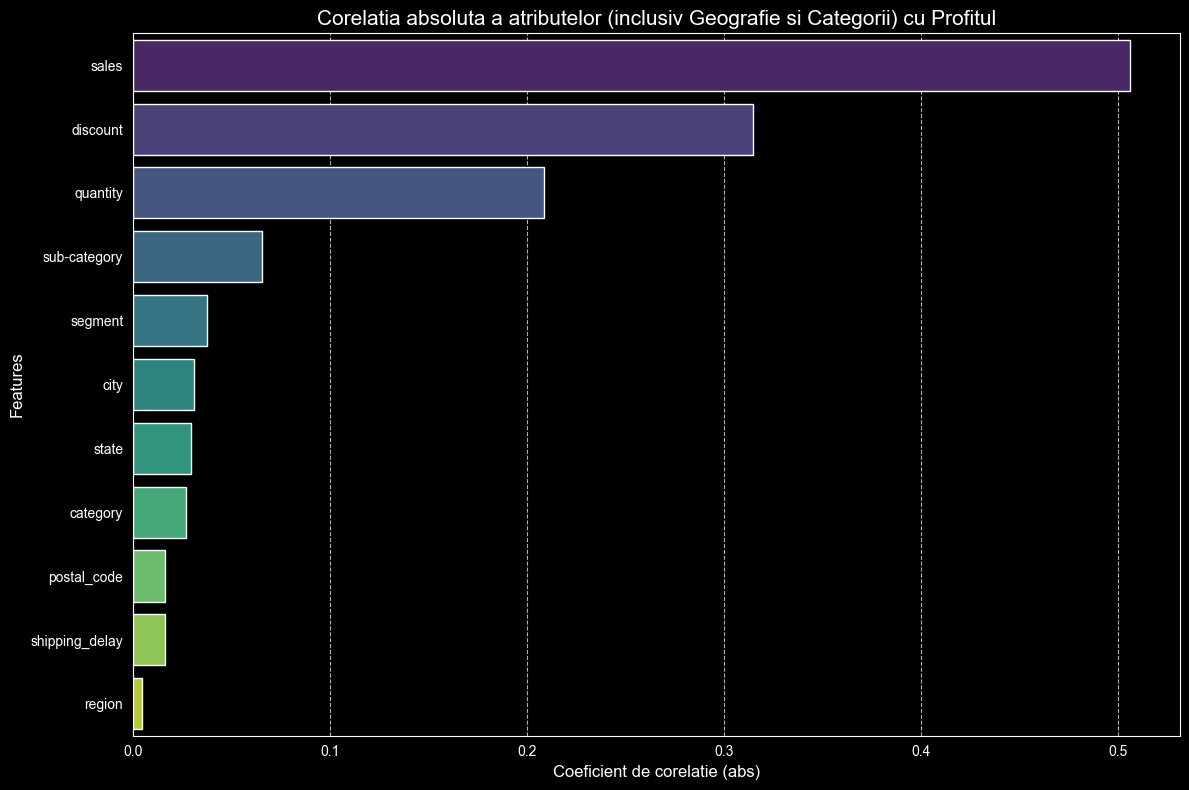

Ierarhia factorilor care influenteaza profitul per client:
total_customer_profit    1.000000
sales                    0.506351
quantity                 0.208503
segment                  0.037422
city                     0.031088
state                    0.029350
shipping_delay           0.016160
region                  -0.004310
postal_code             -0.016379
category                -0.027109
sub-category            -0.065305
discount                -0.314971
Name: total_customer_profit, dtype: float64


In [4]:
# profitul pe customer_id
customer_stats = raw_data.groupby('customer_id').agg({
    'profit': 'sum',
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'shipping_delay': 'mean',
    'segment': 'first',
    'region': 'first',
    'state': 'first',
    'city': 'first',
    'category': 'first',
    'sub-category': 'first',
    'postal_code': 'first'
}).rename(columns={'profit': 'total_customer_profit'})


le = LabelEncoder()
categorical_features = ['segment', 'region', 'state', 'city', 'category', 'sub-category']

for col in categorical_features:
    customer_stats[col] = le.fit_transform(customer_stats[col].astype(str))
corr_matrix = customer_stats.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de Corelatie Extinsa - Indicatori din raw_data')
plt.tight_layout()
plt.show()

profit_corr = corr_matrix['total_customer_profit'].abs().sort_values(ascending=False)
profit_corr = profit_corr.drop(labels=['total_customer_profit'])

plt.figure(figsize=(12, 8))
sns.barplot(x=profit_corr.values, y=profit_corr.index, palette='viridis', hue=profit_corr.index, legend=False)
plt.title('Corelatia absoluta a atributelor (inclusiv Geografie si Categorii) cu Profitul', fontsize=15)
plt.xlabel('Coeficient de corelatie (abs)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Ierarhia factorilor care influenteaza profitul per client:")
print(corr_matrix['total_customer_profit'].sort_values(ascending=False))